# Character level language model - Dinausor land.

Welcome to Dinosaurus Island! 65 million years ago, dinosaurs existed, and here they are back. We are in charge of a special task. Leading biology researchers are creating new breeds of dinosaurs and bringing them to life on earth, and our job is to give names to these dinosaurs. If a dinosaur does not like its name, it might go beserk, so choose wisely!


Luckily you have learned some deep learning and you will use it to save the day. Your assistant has collected a list of all the dinosaur names they could find, and compiled them into a dataset. To create new dinosaur names, you will build a character level language model to generate new names. Your algorithm will learn the different name patterns, and randomly generate new names. Hopefully this algorithm will keep you and your team safe from the dinosaurs' wrath!

Here we learn:
 * How to store text data for processing using an RNN
  * How to synthesize data, by sampling predictions at each time step and passing it to the next RNN-cell unit
  *  How to build a character-level text generation recurrent neural network
  *  Why clipping the gradients is important


We will begin by loading in some functions that we have provided for you in rnn_utils. Specifically, we have access to functions such as rnn_forward and rnn_backward which are equivalent to those we've implemented in the previous assignment.

In [1]:
import numpy as np
from utils import *
import random


## Problem statement.

### Dataset and Preprocessing.
We run the following cell to read the dataset of dinosaur names, create a list of unique characters (such as a-z), and compute the dataset and vocabulary size.


In [2]:
data = open('dinos.txt', 'r').read()

data = data.lower()
chars = list(set(data))
data_size, vocab_size = len(data), len(chars)
print('There are %d total characters and %d unique characters in your data.' % (data_size, vocab_size))

There are 19909 total characters and 27 unique characters in your data.




The characters are a-z (26 characters) plus the "\n" (or newline character), which in this assignment plays a role similar to the `<EOS>` (or "End of sentence") token, here it indicates the end of the dinosaur name rather than the end of a sentence. In the cell below, we create a python dictionary (i.e., a hash table) to map each character to an index from 0-26. We also create a second python dictionary that maps each index back to the corresponding character character. This will help you figure out what index corresponds to what character in the probability distribution output of the softmax layer. Below, char_to_ix and ix_to_char are the python dictionaries.


In [3]:
char_to_ix = { ch:i for i , ch in enumerate(sorted(chars))}

ix_to_char = { i:ch for i, ch in enumerate(sorted(chars))}
print(ix_to_char)
# print(len(ix_to_char))

{0: '\n', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


## Over view of the model.
The model will have the following structure.

* Initialize the model.
* Run the optimization loop.
  * Forward propaation to compute the loss function.
  * Backward propagation to compute the gradients w.r.t the loss function.
  * Clip the gradients to avoid exploding gradients.
  * Using the gradients, update the parameter with the gradient descent upate rule.
* Return the learned parameters

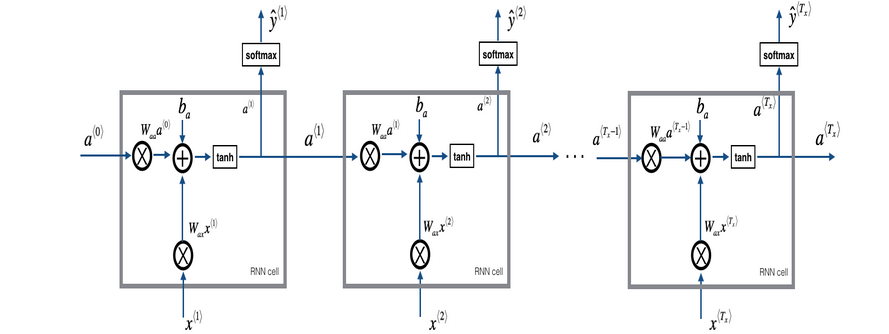
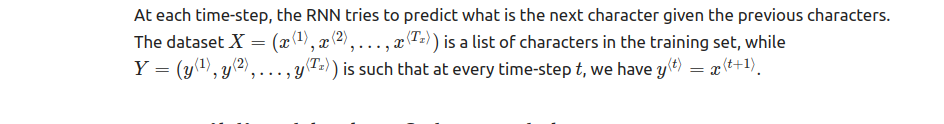

## Building blocks of the model.

IN this part we'll build 2 important blocks of the overall model.
* Gradient clipping: to avoid exploding gradients

* Sampling : a technique to generate characters.

You will then apply these two functions to build the model.

### Clipping the gradient in the optimization loop.

In this section we will implement the clip function that we will call inside of your optimization loop. Recall that your overall loop structure usually consists of a forward pass, a cost computation, a backward pass, and a parameter update. Before updating the parameters, we will perform gradient clipping when needed to make sure that our gradients are not "exploding," meaning taking on overly large values.

In the exercise below, we will implement a function clip that takes in a dictionary of gradients and returns a clipped version of gradients if needed. There are different ways to clip gradients; we will use a simple element-wise clipping procedure, in which every element of the gradient vector is clipped to lie between some range [-N, N]. More generally, you will provide a `maxValue` (say 10). In this example, if any component of the gradient vector is greater than 10, it would be set to 10; and if any component of the gradient vector is less than -10, it would be set to -10. If it is between -10 and 10, it is left alone.

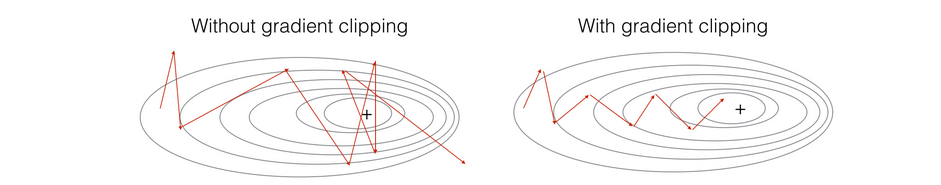
 **Figure 2**: Visualization of gradient descent with and without gradient clipping, in a case where the network is running into slight "exploding gradient" problems.


Let implement the fn: that return clipped gradients of the dictionary `gradients`. Our function takes in a maximum threshold and returns the clippend versions of the gradients.

In [4]:
def clip(gradients, maxValue):
  dWaa, dWax, dWya, db, dby = gradients['dWaa'], gradients['dWax'], gradients['dWya'], gradients['db'], gradients['dby']

  ### START CODE HERE ###
  # clip to mitigate exploding gradients, loop over [dWax, dWaa, dWya, db, dby]. (≈2 lines)
  for gradient in [dWax, dWaa, dWya, db, dby]:
      np.clip(gradient, -maxValue, maxValue, out=gradient)
  ### END CODE HERE ###

  gradients = {"dWaa": dWaa, "dWax": dWax, "dWya": dWya, "db": db, "dby": dby}

  return gradients



In [5]:
np.random.seed(3)
dWax = np.random.randn(5,3)*10
dWaa = np.random.randn(5,5)*10
dWya = np.random.randn(2,5)*10
db = np.random.randn(5,1)*10
dby = np.random.randn(2,1)*10

gradients = {"dWax": dWax, "dWaa": dWaa, "dWya": dWya, "db": db, "dby": dby}
gradients = clip(gradients, 10)

print("gradients[\"dWaa\"][1][2] =", gradients["dWaa"][1][2])
print("gradients[\"dWax\"][3][1] =", gradients["dWax"][3][1])
print("gradients[\"dWya\"][1][2] =", gradients["dWya"][1][2])
print("gradients[\"db\"][4] =", gradients["db"][4])
print("gradients[\"dby\"][1] =", gradients["dby"][1])

gradients["dWaa"][1][2] = 10.0
gradients["dWax"][3][1] = -10.0
gradients["dWya"][1][2] = 0.2971381536101662
gradients["db"][4] = [10.]
gradients["dby"][1] = [8.45833407]


### Sampling
Now assume that your model is trained. You would like to generate new text (characters). The process of generation is explained in the picture below:

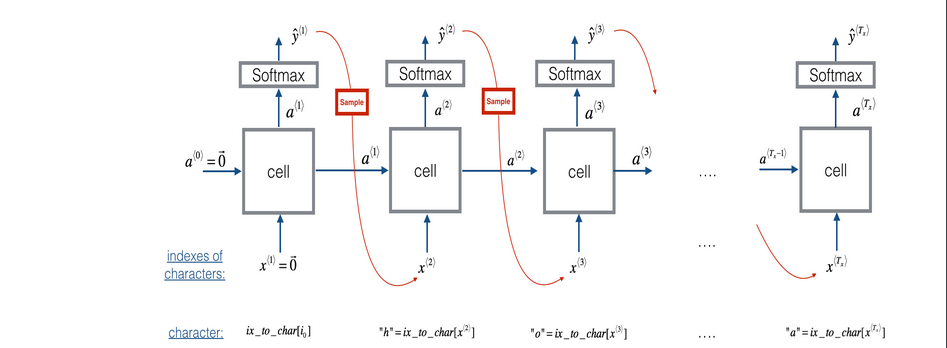
**Figure 3**: In this picture, we assume the model is already trained. We pass in $x^{(t)}$ = 0
at the first time step, and have the network then sample one character at a time


Now we implement the sample function below to sample characters. We need to carry out 4 steps:

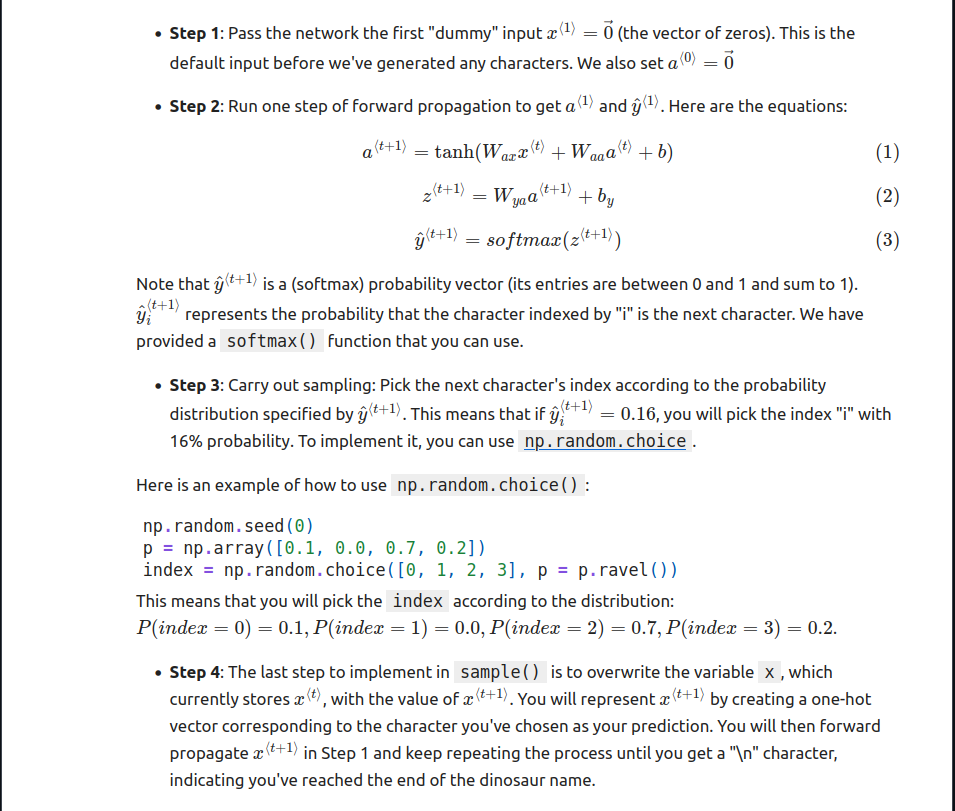


In [6]:
def sample(parameters, char_to_ix, seed):
  """
  Sample a sequence of characters according to a sequence of probability distributions output of the RNN

  Arguments:
  parameters -- python dictionary containing the parameters Waa, Wax, Wya, by, and b.
  char_to_ix -- python dictionary mapping each character to an index.
  seed -- used for grading purposes. Do not worry about it.

  Returns:
  indices -- a list of length n containing the indices of the sampled characters.
  """
  # Retrieve parameters and relevant shapes from "parameters" dictionary
  Waa, Wax, Wya, by, b = parameters['Waa'], parameters['Wax'], parameters['Wya'], parameters['by'], parameters['b']

  vocab_size = by.shape[0]
  n_a = Waa.shape[1]

  # Step 1: Create the one-hot vector x for the first character (initializing the sequence generation).
  x = np.zeros((vocab_size, 1))
  # Step 1. Initialize a_prev as zeros
  a_prev = np.zeros((n_a, 1))

  # Create an empty list of indices, this is the list which will contain the list of indices of the characters to generate.
  indices = []

  # Idx is a flag to detect a newline character, we initialize it to -1.
  idx = -1

  # Loop over time-steps t. At each time-step, sample a character from a probability distribution and append
  # its index to "indices". We'll stop if we reach 50 characters (which should be very unlikely with a well
  # trained model), which helps debugging and prevents entering an infinite loop.

  counter = 0
  newline_character = char_to_ix['\n']

  while (idx != newline_character and counter != 50):

    # Step 2: Forward propagate x using the equations (1), (2), and (3).
    a = np.tanh(np.dot(Wax, x) + np.dot(Waa, a_prev) + b)
    z = np.dot(Wya, a) + by
    y = softmax(z)

    np.random.seed(counter+seed)

    # Step 3: Sample the index of a character within the vocabulary from the probability distribution y
    idx = np.random.choice(list(range(vocab_size)), p=y.ravel())

    # Append the index to "indices".
    indices.append(idx)

    # Step 4: Overwrite the input character as the one corresponding to the sampled index.
    x = np.zeros((vocab_size, 1))
    x[idx] = 1

    # Update "a_prev" to be "a"
    a_prev = a

    seed += 1
    counter += 1

  if (counter  == 50):
    indices.append(char_to_ix['\n'])
  return indices















In [7]:


np.random.seed(2)
_, n_a = 20, 100

Wax, Waa, Wya = np.random.randn(n_a, vocab_size), np.random.randn(n_a, n_a), np.random.randn(vocab_size, n_a)
b, by = np.random.randn(n_a, 1), np.random.randn(vocab_size, 1)
parameters = {"Wax": Wax, "Waa": Waa, "Wya": Wya, "b": b, "by": by}

indices = sample(parameters, char_to_ix, 0)
print("Sampling:")
print("list of sampled indices:", indices, '\n')
print("list of sampled characters:", [ix_to_char[i] for i in indices])



Sampling:
list of sampled indices: [np.int64(12), np.int64(17), np.int64(24), np.int64(14), np.int64(13), np.int64(9), np.int64(10), np.int64(22), np.int64(24), np.int64(6), np.int64(13), np.int64(11), np.int64(12), np.int64(6), np.int64(21), np.int64(15), np.int64(21), np.int64(14), np.int64(3), np.int64(2), np.int64(1), np.int64(21), np.int64(18), np.int64(24), np.int64(7), np.int64(25), np.int64(6), np.int64(25), np.int64(18), np.int64(10), np.int64(16), np.int64(2), np.int64(3), np.int64(8), np.int64(15), np.int64(12), np.int64(11), np.int64(7), np.int64(1), np.int64(12), np.int64(10), np.int64(2), np.int64(7), np.int64(3), np.int64(11), np.int64(2), np.int64(6), np.int64(12), np.int64(13), np.int64(15), 0] 

list of sampled characters: ['l', 'q', 'x', 'n', 'm', 'i', 'j', 'v', 'x', 'f', 'm', 'k', 'l', 'f', 'u', 'o', 'u', 'n', 'c', 'b', 'a', 'u', 'r', 'x', 'g', 'y', 'f', 'y', 'r', 'j', 'p', 'b', 'c', 'h', 'o', 'l', 'k', 'g', 'a', 'l', 'j', 'b', 'g', 'c', 'k', 'b', 'f', 'l', 'm', 'o'

## Building the Language model.
In this section we will implement a function performing one step of stochastic gradient descent (with clipped gradients). we will go through the training examples one at a time, so the optimization algorithm will be stochastic gradient descent. As a reminder, here are the steps of a common optimization loop for an RNN:

* Forward propagate through the RNN to compute the loss
* Backward propagate through time to compute the gradients of the loss with respect to the parameters
* Clip the gradients if necessary
* Update your parameters using gradient descent


Let implement the optimization process (one step of stochastic gradient descent)

We've these following functions.

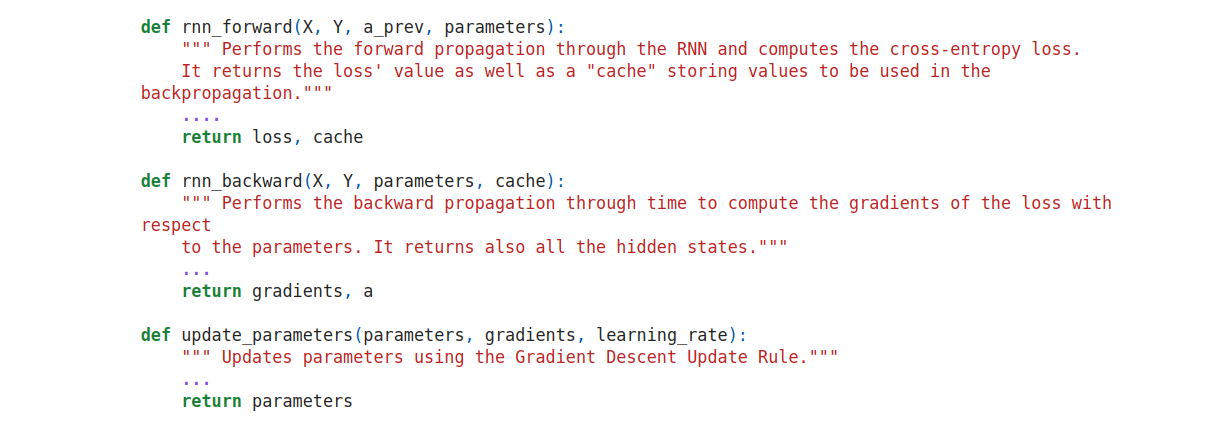

In [8]:
def optimize(X, Y, a_prev, parameters, learning_rate=0.01):
  """
  Execute one step of the optimization to train the model.

  Arguments:
  X -- list of integers, where each integer is a number that maps to a character in the vocabulary.
  Y -- list of integers, exactly the same as X but shifted one index to the left.
  a_prev -- previous hidden state.
  parameters -- python dictionary containing:
                      Wax -- Weight matrix multiplying the input, numpy array of shape (n_a, n_x)
                      Waa -- Weight matrix multiplying the hidden state, numpy array of shape (n_a, n_a)
                      Wya -- Weight matrix relating the hidden-state to the output, numpy array of shape (n_y, n_a)
                      b --  Bias, numpy array of shape (n_a, 1)
                      by -- Bias relating the hidden-state to the output, numpy array of shape (n_y, 1)
  learning_rate -- learning rate for the model.

  Returns:
  loss -- value of the loss function (cross-entropy)
  gradients -- python dictionary containing:
                      dWax -- Gradients of input-to-hidden weights, of shape (n_a, n_x)
                      dWaa -- Gradients of hidden-to-hidden weights, of shape (n_a, n_a)
                      dWya -- Gradients of hidden-to-output weights, of shape (n_y, n_a)
                      db -- Gradients of bias vector, of shape (n_a, 1)
                      dby -- Gradients of output bias vector, of shape (n_y, 1)
  a[len(X)-1] -- the last hidden state, of shape (n_a, 1)
  """
  # Forward propagate through time
  loss, cache = rnn_forward(X, Y, a_prev, parameters)

  # Backpropagate through time
  gradients , a = rnn_backward(X, Y, parameters, cache)

  # clip the gradients between -5 (min) and 5 (max)
  gradients = clip(gradients, maxValue=5)

  # updaing the parameters
  parameters = update_parameters(parameters, gradients, learning_rate)

  return loss, gradients, a[len(X) - 1]



In [9]:
def update_parameters(parameters, gradients, learning_rate):
    """
    Update parameters using gradient descent
    """

    parameters["Wax"] -= learning_rate * gradients["dWax"]
    parameters["Waa"] -= learning_rate * gradients["dWaa"]
    parameters["Wya"] -= learning_rate * gradients["dWya"]
    parameters["b"]   -= learning_rate * gradients["db"]
    parameters["by"]  -= learning_rate * gradients["dby"]

    return parameters


In [10]:
np.random.seed(1)
vocab_size, n_a = 27, 100
a_prev = np.random.randn(n_a, 1)
Wax, Waa, Wya = np.random.randn(n_a, vocab_size), np.random.randn(n_a, n_a), np.random.randn(vocab_size, n_a)
b, by = np.random.randn(n_a, 1), np.random.randn(vocab_size, 1)

parameters = {"Wax": Wax, "Waa": Waa, "Wya": Wya, "b": b, "by": by}
X = [12,3,5,11,22,3]
Y = [4,14,11,22,25, 26]

loss, gradients, a_last = optimize(X, Y, a_prev, parameters, learning_rate = 0.01)
print("Loss =", loss)
print("gradients[\"dWaa\"][1][2] =", gradients["dWaa"][1][2])
print("np.argmax(gradients[\"dWax\"]) =", np.argmax(gradients["dWax"]))
print("gradients[\"dWya\"][1][2] =", gradients["dWya"][1][2])
print("gradients[\"db\"][4] =", gradients["db"][4])
print("gradients[\"dby\"][1] =", gradients["dby"][1])
print("a_last[4] =", a_last[4])


Loss = 126.50397572165383
gradients["dWaa"][1][2] = 0.1947093153471555
np.argmax(gradients["dWax"]) = 93
gradients["dWya"][1][2] = -0.007773876032002889
gradients["db"][4] = [-0.06809825]
gradients["dby"][1] = [0.01538192]
a_last[4] = [-1.]


## Training the model
Given the dataset of dinosaur names, we use each line of the dataset (one name) as one training example. Every 100 steps of stochastic gradient descent, you will sample 10 randomly chosen names to see how the algorithm is doing. Remember to shuffle the dataset, so that stochastic gradient descent visits the examples in random order.

we  follow the instructions and implement model(). When examples[index] contains one dinosaur name (string), to create an example (X, Y), we use this:

        index = j % len(examples)
        X = [None] + [char_to_ix[ch] for ch in examples[index]]
        Y = X[1:] + [char_to_ix["\n"]]

Note that we use: index= j % len(examples), where j = 1....num_iterations, to make sure that examples[index] is always a valid statement (index is smaller than len(examples)). The first entry of X being None will be interpreted by rnn_forward() as setting $x^{(0)} = 0$
. Further, this ensures that Y is equal to X but shifted one step to the left, and with an additional "\n" appended to signify the end of the dinosaur name.


In [11]:
def smooth(loss, cur_loss):
  return loss * 0.999 - cur_loss * 0.001

In [12]:
def get_initial_loss(vocab_size, dino_names):
  return -np.log(1.0 / vocab_size) * dino_names


In [15]:
def model(data, ix_to_char, char_to_ix, num_iterations=35000, n_a= 50, dino_names=7, vocab_size=27):
  """
  Trains the model and generates dinosaur names.

  Arguments:
  data -- text corpus
  ix_to_char -- dictionary that maps the index to a character
  char_to_ix -- dictionary that maps a character to an index
  num_iterations -- number of iterations to train the model for
  n_a -- number of units of the RNN cell
  dino_names -- number of dinosaur names you want to sample at each iteration.
  vocab_size -- number of unique characters found in the text, size of the vocabulary

  Returns:
  parameters -- learned parameters

  """

  n_x, n_y = vocab_size, vocab_size

  parameters = initialize_parameters(n_a, n_x, n_y)

  # Initialize the loss
  loss = get_initial_loss(vocab_size, dino_names)

  # Build list of all dinosaur names (training examples).
  with open('dinos.txt') as f:
    examples = f.readlines()
  examples = [x.lower().strip() for x in examples]

  np.random.seed(0)
  np.random.shuffle(examples)

  # Initialize the hidden state of the RNN.
  a_prev = np.zeros((n_a, 1))

  # optimization loop
  for j in range(num_iterations):
    index = j % len(examples)
    X = [None] + [char_to_ix[ch] for ch in examples[index]]
    Y  = X[1: ] + [char_to_ix["\n"]]

    curr_loss, gradients, a_prev = optimize(X, Y, a_prev, parameters, learning_rate = 0.01)

    loss = smooth(loss, curr_loss)

    if j % 2000 == 0:

      print("Iteration: %d, Loss: %f" % (j, loss) + "\n")

      seed = 0
      for name in range(dino_names):

        sampled_indices = sample(parameters, char_to_ix, seed)
        print_sample(sampled_indices, ix_to_char)
        seed += 1

      print("\n")

  return parameters




If we run the following cell, we should observe your model outputting random-looking characters at the first iteration. After a few thousand iterations, your model should learn to generate reasonable-looking names.


In [16]:
parameters = model(data, ix_to_char, char_to_ix)

Iteration: 0, Loss: 23.008240

nkzxwtdmfqoeyhsqwasjkjvu
kneb
kzxwtdmfqoeyhsqwasjkjvu
neb
zxwtdmfqoeyhsqwasjkjvu
eb
xwtdmfqoeyhsqwasjkjvu


Iteration: 2000, Loss: -20.707505

opusaurus
kon
lwtos
on
xusaurus
edalosaurus
usaurus


Iteration: 4000, Loss: -24.149027

orusaurus
lon
mytos
on
xus
ef
usaurus


Iteration: 6000, Loss: -23.761210

ostus
lon
mytos
on
xus
eg
us


Iteration: 8000, Loss: -23.337538

orvtos
nora
otosaurus
on
xus
haados
usaurus


Iteration: 10000, Loss: -23.089933

onyxlus
ina
lus
oha
xus
ee
us


Iteration: 12000, Loss: -22.501593

oslusura
kima
lusaurus
on
wsosaurus
ehagosaurus
usaurus


Iteration: 14000, Loss: -22.454965

onus
inee
lusaurus
oha
xus
haberlia
us


Iteration: 16000, Loss: -22.401901

onyxtr
ilacados
iusaurus
ode
usaurus
eg
us


Iteration: 18000, Loss: -21.984532

oslus
loma
musnus
ona
vosaurus
ha
us


Iteration: 20000, Loss: -22.065313

orus
inchahron
iusiter
oga
vosaurus
elagosaurus
usaurus


Iteration: 22000, Loss: -21.910168

onyx
imeh
kusaurus
ode
us

## Conclusion

We can see that our algorithm has started to generate plausible dinosaur names towards the end of the training. At first, it was generating random characters, but towards the end We could see dinosaur names with cool endings. IF we were to run the algorithm even longer and play with hyperparameters we  see We can get even better results. Our implemetation generated some really cool names like maconucon, marloralus and macingsersaurus. Our model hopefully also learned that dinosaur names tend to end in saurus, don, aura, tor, etc.

If your model generates some non-cool names, don't blame the model entirely--not all actual dinosaur names sound cool. (For example, dromaeosauroides is an actual dinosaur name and is in the training set.) But this model should give you a set of candidates from which you can pick the coolest!

Here we had used a relatively small dataset, so that you could train an RNN quickly on a CPU. Training a model of the english language requires a much bigger dataset, and usually needs much more computation, and could run for many hours on GPUs. We ran our dinosaur name for quite some time, and so far our favoriate name is the great, undefeatable, and fierce: Mangosaurus!


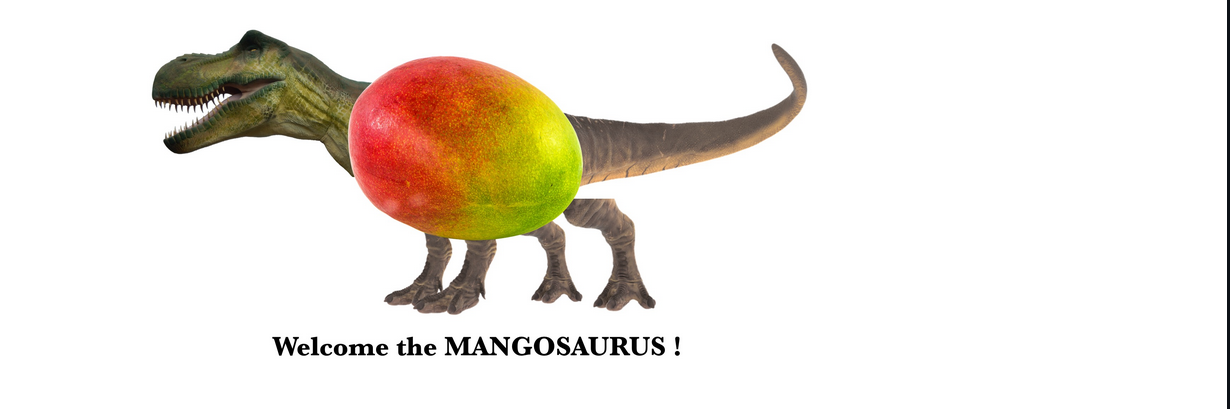

## Writing like shapkespeare ...???
'''Tomorrow, and tomorrow, and tomorrow,
Creeps in this petty pace from day to day
To the last syllable of recorded time;
And all our yesterdays have lighted fools
The way to dusty death. Out, out, brief candle!
Life’s but a walking shadow, a poor player
That struts and frets his hour upon the stage
And then is heard no more. It is a tale
Told by an idiot, full of sound and fury,
Signifying nothing.
''' ????




A similar (but more complicated) task is to generate Shakespeare poems. Instead of learning from a dataset of Dinosaur names you can use a collection of Shakespearian poems. Using LSTM cells, you can learn longer term dependencies that span many characters in the text--e.g., where a character appearing somewhere a sequence can influence what should be a different character much much later in ths sequence. These long term dependencies were less important with dinosaur names, since the names were quite short.


Let become poet ✍
We have implemented a Shakespeare poem generator with Keras. Run the following cell to load the required packages and models. This may take a few minutes.

In [ ]:
from __future__ import print_function
from keras.callbacks import LambdaCallback
from keras.models import Model, load_model, Sequential
from keras.layers import Dense, Activation, Dropout, Input, Masking
from keras.layers import LSTM
from keras.utils.data_utils import get_file
from keras.preprocessing.sequence import pad_sequences
from shakespeare_utils import *
import sys
import io



Let's train the model for one more epoch. When it finishes training for an epoch---this will also take a few minutes---you can run generate_output, which will prompt asking you for an input (<40 characters). The poem will start with your sentence, and our RNN-Shakespeare will complete the rest of the poem for you! For example, try "Forsooth this maketh no sense " (don't enter the quotation marks). Depending on whether you include the space at the end, your results might also differ--try it both ways, and try other inputs as well.


In [ ]:
print_callback = LambdaCallback(on_epoch_end = on_epoch_end)

model.fit(x, y, batch_size =128, epochs=1, callbacks=[print_callback])

In [ ]:
# Run this cell to try with different inputs without having to re-train the model
generate_output()

The RNN-Shakespeare model is very similar to the one you have built for dinosaur names. The only major differences are:

    * LSTMs instead of the basic RNN to capture longer-range dependencies
    * The model is a deeper, stacked LSTM model (2 layer)
    * Using Keras instead of python to simplify the code
